# Project proposal — candidate problem statements

### Freight economics on the Olist Brazilian E-Commerce dataset

This notebook is a **decision document**, not an analysis. It sets out four candidate
problem statements, computes the evidence that each one rests on, and recommends a
combination.

Every number below is calculated live from the CSVs rather than quoted, so the proposal
can be read and checked on its own. The full analysis behind them is in
`03_freight_economics.ipynb`; the delivery and satisfaction work they connect to is in
`01_olist_eda.ipynb` and `02_expectation_error.ipynb`.

| | Candidate | One-line claim |
|---|---|---|
| **A** | The consolidation penalty | Freight is charged per item, taxing basket growth |
| **B** | Regressive freight | A fixed base fee makes cheap categories uncompetitive |
| **C** | Two freight problems | Cost concentrates short-haul, burden concentrates long-haul |
| **D** | What freight does not explain | The freight–satisfaction link is confounded by distance |

**A note on scope.** All four sit inside EDA and visualisation. None requires modelling
beyond a descriptive linear fit, and each is answerable with the nine CSVs as they
stand.

## 1. Evidence base

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import olist_theme as T
import olist_data as OD

T.apply_theme()
pd.set_option("display.width", 150)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

raw    = OD.load_all()
items  = OD.item_level(raw)     # one row per item line, with seller->customer distance
orders = OD.order_level(raw)    # one row per order

FREIGHT_TOTAL = items.freight_value.sum()
ITEM_TOTAL    = items.price.sum()

print(f"item lines             {len(items):,}")
print(f"orders                 {len(orders):,}")
print(f"freight charged        R$ {FREIGHT_TOTAL:,.0f}")
print(f"item revenue           R$ {ITEM_TOTAL:,.0f}")
print(f"freight share of GMV   {100*FREIGHT_TOTAL/(FREIGHT_TOTAL+ITEM_TOTAL):.1f}%")
print(f"orders shipped free    {100*orders.freight_total.eq(0).mean():.2f}%")

item lines             112,650
orders                 99,441
freight charged        R$ 2,251,910
item revenue           R$ 13,591,644
freight share of GMV   14.2%
orders shipped free    0.34%


## 2. Statement A — The consolidation penalty

> **Olist charges freight per item line rather than per shipment, so a customer buying
> multiple units from a single seller pays multiple shipping fees. This project
> quantifies the resulting overcharge and argues that the fee structure taxes precisely
> the basket growth a marketplace with a 3% repeat rate most needs to encourage.**

**Sub-questions**

1. Is freight charged per order or per item — and how do we prove which?
2. What did customers overpay against a one-charge-per-seller counterfactual?
3. Which categories and regions absorb that penalty?
4. Why is the observable figure a floor rather than the true cost?

In [2]:
# --- proof: N copies of ONE product from ONE seller ---------------------------
g = items.groupby("order_id").agg(
    n=("freight_value", "size"), n_products=("product_id", "nunique"),
    n_sellers=("seller_id", "nunique"), total=("freight_value", "sum"),
    per_line=("freight_value", "median"), distinct=("freight_value", "nunique"))

same = g[(g.n > 1) & (g.n_products == 1) & (g.n_sellers == 1) & (g.n <= 6)]
tab = same.groupby("n").agg(orders=("total", "size"),
                            median_total=("total", "median"),
                            median_per_line=("per_line", "median"))
single = g.loc[g.n == 1, "total"].median()

# --- the money: counterfactual of one charge per seller per order -------------
multi = g[g.n > 1]
overpay = (multi.total - multi.per_line * multi.n_sellers).clip(lower=0)
repeat = raw["customers"].groupby("customer_unique_id").size()

print(f"multi-line orders                    {len(multi):,} ({100*len(multi)/len(g):.1f}% of orders)")
print(f"every line same freight              {100*multi.distinct.eq(1).mean():.1f}%")
print(f"CUSTOMER OVERPAYMENT                 R$ {overpay.sum():,.0f} "
      f"({100*overpay.sum()/FREIGHT_TOTAL:.1f}% of all freight revenue)")
print(f"median overpay on affected orders    R$ {overpay[overpay>0].median():.2f}")
print(f"repeat-purchase rate (the context)   {100*(repeat>1).mean():.2f}%")
tab.round(2)

multi-line orders                    9,803 (9.9% of orders)
every line same freight              79.3%
CUSTOMER OVERPAYMENT                 R$ 234,120 (10.4% of all freight revenue)
median overpay on affected orders    R$ 17.60
repeat-purchase rate (the context)   3.12%


,orders,median_total,median_per_line
n,,,
2,5005,31.26,15.63
3,865,48.33,16.11
4,361,64.44,16.11
5,158,74.38,14.88
6,157,96.66,16.11


findfont: Failed to find font weight semibold, now using 700.


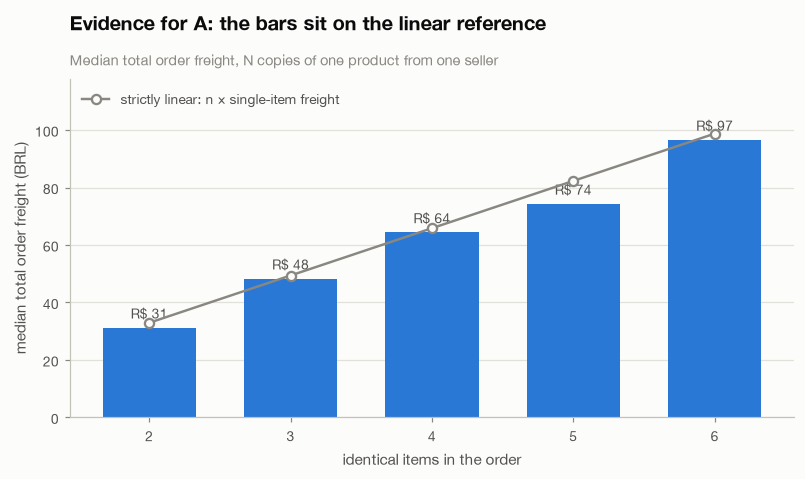

In [3]:
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.bar(tab.index.astype(int).astype(str), tab.median_total, color=T.CAT[0], width=0.66)
T.label_bars(ax, fmt="R$ {:.0f}", size=9)
ax.plot(np.arange(len(tab)), [single * n for n in tab.index], color=T.MUTED, lw=1.6,
        marker="o", markersize=6, markerfacecolor=T.SURFACE, markeredgewidth=1.5,
        zorder=4, label="strictly linear: n × single-item freight")
ax.legend(loc="upper left")
T.title(ax, "Evidence for A: the bars sit on the linear reference",
        "Median total order freight, N copies of one product from one seller")
ax.set_xlabel("identical items in the order")
ax.set_ylabel("median total order freight (BRL)")
ax.set_ylim(0, tab.median_total.max() * 1.22)
plt.show()

**Strength.** A structural fact proved by a clean test, with money attached. The
competing explanation — that Olist charges once per order and merely *allocates* it
across lines — predicts a flat total, and the total is not flat.

**Risk.** The counterfactual (one charge per seller) is a modelling choice, not a fact.
State it as an assumption and report the result as an order of magnitude.

## 3. Statement B — Regressive freight and category viability

> **Olist's freight is dominated by a fixed base fee of roughly R$8, so shipping falls
> from over 60% of item value on cheap goods to under 4% on expensive ones. This project
> examines how that regressivity shapes which categories can compete on the platform.**

**Sub-questions**

1. Can the pricing rule be recovered from the data, and what is its fixed component?
2. How does burden vary across price bands, categories and regions?
3. Which categories are structurally disadvantaged — and is that about their shipping
   cost or their price?
4. What would a threshold-based free-shipping policy cost?

In [4]:
beta, r2, _ = OD.fit_tariff(items)
print(f"freight ≈ {beta[0]:.2f} + {beta[1]:.5f}·km + {beta[2]:.2f}·kg + {beta[3]:.3f}·litre"
      f"   (R² = {r2:.3f})")
print(f"  fixed base fee            R$ {beta[0]:.2f}")
print(f"  as share of median freight {100*beta[0]/items.freight_value.median():.0f}%\n")

pb = pd.cut(items.price, [0, 30, 60, 100, 200, 500, np.inf],
            labels=["<30", "30–60", "60–100", "100–200", "200–500", "500+"])
band = items.groupby(pb, observed=True).agg(
    lines=("burden", "size"), median_freight=("freight_value", "median"),
    median_burden=("burden", "median"))
print("Burden by item price band:")
print(band.round(1).to_string())

cat = (items.groupby("category")
       .agg(lines=("burden", "size"), median_price=("price", "median"),
            median_freight=("freight_value", "median"),
            median_burden=("burden", "median")).query("lines >= 200"))
print("\nThe comparison that makes the point -- near-identical freight, opposite burdens:")
print(cat.loc[cat.index.intersection(["electronics", "watches_gifts"])].round(1).to_string()
      if len(cat.index.intersection(["electronics", "watches_gifts"])) == 2
      else pd.concat([cat.nlargest(2, "median_burden"),
                      cat.nsmallest(2, "median_burden")]).round(1).to_string())

freight ≈ 7.90 + 0.01038·km + 1.64·kg + 0.158·litre   (R² = 0.574)
  fixed base fee            R$ 7.90
  as share of median freight 49%



Burden by item price band:
         lines  median_freight  median_burden
price                                        
<30      20285           14.10          62.20
30–60    28433           15.10          31.80
60–100   23619           16.40          20.10
100–200  26939           18.50          13.50
200–500  10158           21.00           7.70
500+      3216           31.30           3.80

The comparison that makes the point -- near-identical freight, opposite burdens:
               lines  median_price  median_freight  median_burden
category                                                         
electronics     2767         21.90           15.10          62.30
watches_gifts   5991        129.00           15.80          11.50


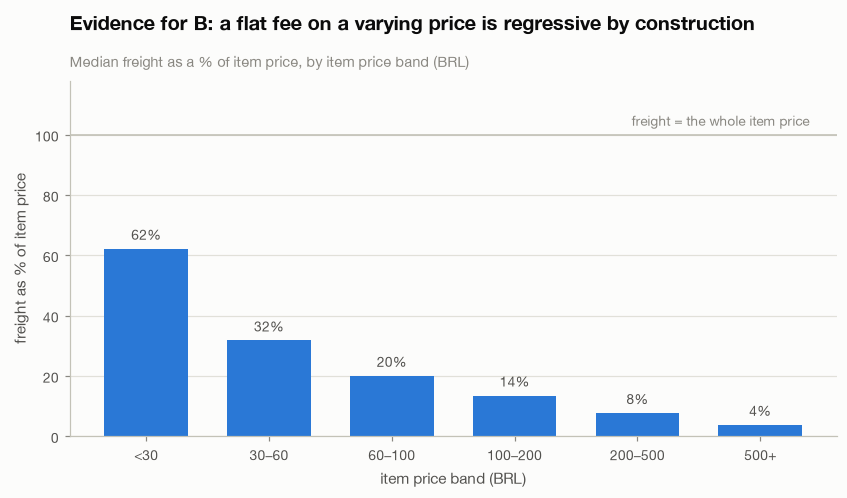

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.bar(band.index.astype(str), band.median_burden, color=T.CAT[0], width=0.68)
T.label_bars(ax, fmt="{:.0f}%", size=9)
ax.axhline(100, color=T.AXIS, lw=1.1)
ax.annotate("freight = the whole item price", (5.4, 100), xytext=(0, 6),
            textcoords="offset points", ha="right", fontsize=9, color=T.MUTED)
T.title(ax, "Evidence for B: a flat fee on a varying price is regressive by construction",
        "Median freight as a % of item price, by item price band (BRL)")
ax.set_xlabel("item price band (BRL)"); ax.set_ylabel("freight as % of item price")
ax.set_ylim(0, 118)
plt.show()

**Strength.** The tariff fit supplies a *mechanism* rather than a description, so the
project explains rather than reports. The free-shipping analysis adds a genuine negative
result, which is harder to argue with than a positive one.

**Risk.** R² = 0.57 — roughly half the variance is unexplained. Present the fit as an
approximation of the pricing rule, never as the rule itself.

## 4. Statement C — Two freight problems, not one

> **Freight *spend* concentrates in short-haul metropolitan lanes while freight *burden*
> concentrates in remote long-haul ones. This project separates the cost-reduction
> problem from the equity problem and shows they require different interventions.**

**Sub-questions**

1. Where does freight spend actually concentrate, by lane?
2. Where does freight burden concentrate?
3. Do those coincide? (They do not.)
4. What follows for where a logistics investment should go?

In [6]:
lanes = (items.dropna(subset=["lane"]).groupby("lane")
         .agg(lines=("freight_value", "size"), freight=("freight_value", "sum"),
              median_km=("km", "median"))
         .sort_values("freight", ascending=False))
lanes["pct_of_freight"] = 100 * lanes.freight / lanes.freight.sum()
print("Top lanes by total freight spend:")
print(lanes.head(5).round(1).to_string())

NE = ["BA", "PE", "CE", "MA", "PB", "RN", "AL", "SE", "PI"]
sp_ne = items.seller_state.eq("SP") & items.customer_state.isin(NE)
sp_sp = items.seller_state.eq("SP") & items.customer_state.eq("SP")
print(f"\nSP -> SP        {100*sp_sp.mean():>5.1f}% of lines | "
      f"{100*items.loc[sp_sp,'freight_value'].sum()/FREIGHT_TOTAL:>5.1f}% of freight | "
      f"median {items.loc[sp_sp,'km'].median():>6.0f} km")
print(f"SP -> Northeast {100*sp_ne.mean():>5.1f}% of lines | "
      f"{100*items.loc[sp_ne,'freight_value'].sum()/FREIGHT_TOTAL:>5.1f}% of freight | "
      f"median {items.loc[sp_ne,'km'].median():>6.0f} km")

Top lanes by total freight spend:
          lines    freight  median_km  pct_of_freight
lane                                                 
SP to SP  36192 477,906.60      94.90           21.20
SP to RJ   9688 198,275.50     383.60            8.80
SP to MG   8703 176,277.80     488.90            7.80
SP to RS   4194  86,975.70     867.70            3.90
SP to PR   3667  75,244.90     420.50            3.30

SP -> SP         32.1% of lines |  21.2% of freight | median     95 km
SP -> Northeast   6.5% of lines |  10.0% of freight | median   1964 km


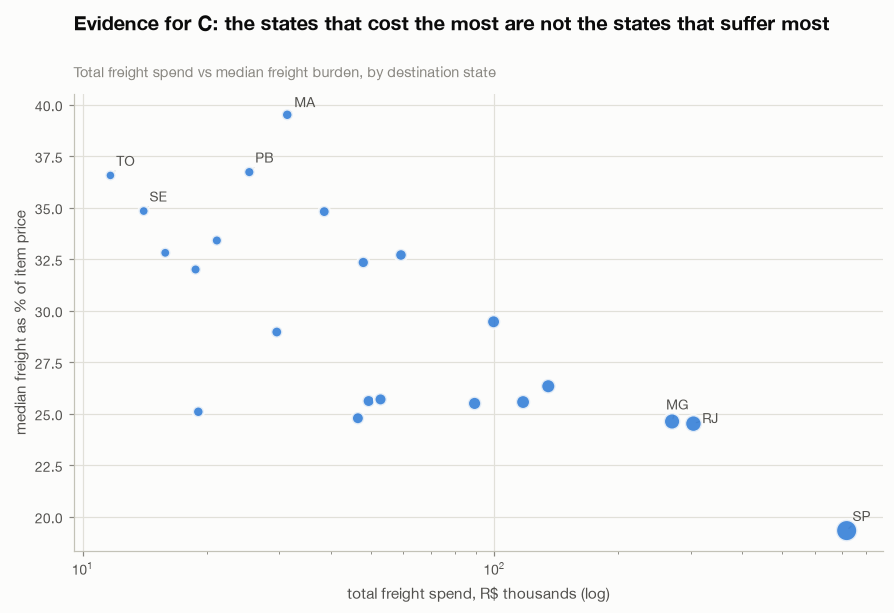

In [7]:
st = (items.dropna(subset=["km"]).groupby("customer_state")
      .agg(lines=("burden", "size"), spend=("freight_value", "sum"),
           median_burden=("burden", "median"))
      .query("lines >= 300"))

from adjustText import adjust_text
fig, ax = plt.subplots(figsize=(9.5, 5.4))
ax.scatter(st.spend / 1000, st.median_burden, s=30 + 170 * (st.lines / st.lines.max()) ** 0.5,
           color=T.CAT_SCATTER[0], edgecolor=T.SURFACE, linewidth=1.7, alpha=0.85, zorder=3)
ax.set_xscale("log")
label = set(st.nlargest(3, "spend").index) | set(st.nlargest(4, "median_burden").index)
texts = [ax.text(st.loc[s].spend / 1000, st.loc[s].median_burden, s,
                 fontsize=9, color=T.INK_2) for s in label]
adjust_text(texts, ax=ax, expand=(1.6, 1.9),
            arrowprops=dict(arrowstyle="-", color=T.AXIS, lw=0.8))
T.title(ax, "Evidence for C: the states that cost the most are not the states that suffer most",
        "Total freight spend vs median freight burden, by destination state")
ax.set_xlabel("total freight spend, R$ thousands (log)")
ax.set_ylabel("median freight as % of item price")
ax.grid(axis="both", visible=True)
plt.show()

**Strength.** It inverts an intuition — the delivery analysis trains you to look at the
Northeast, and the money is in São Paulo. Surprise is worth marks when it is
well-evidenced.

**Risk.** Thinner than A and B on its own. Best used as a section inside B rather than
as a whole project.

## 5. Statement D — What freight does *not* explain

> **Freight burden correlates with customer dissatisfaction, but the relationship
> disappears once delivery time is held constant. This project uses freight as a case
> study in confounding, and delimits what the dataset can and cannot establish about
> customer harm.**

**Sub-questions**

1. What are the raw correlations between distance, freight, delivery time and rating?
2. Does the freight effect survive stratification by delivery time?
3. What causal structure explains the pattern?
4. What would be needed to answer the real question, and why is it absent here?

In [8]:
od = (orders.set_index("order_id")
      .join(items.groupby("order_id").km.median(), how="inner"))
od = od[od.is_delivered & od.actual.notna() & od.review_score.notna()
        & od.item_total.gt(0)].copy()
od["burden"] = 100 * od.freight_total / od.item_total

print("Raw Spearman correlations (all look weak, but weak != spurious):\n")
print(od[["km", "freight_total", "burden", "actual", "review_score"]]
      .corr(method="spearman").round(3).to_string())

db = OD.bucket_actual(od.actual)
fb = pd.cut(od.burden, [0, 15, 30, 50, np.inf], labels=["<15%", "15–30%", "30–50%", "50%+"])
piv = od.groupby([db, fb], observed=True).review_score.mean().unstack()
print("\nMean review score by delivery time (rows) x freight burden (cols):")
print(piv.round(2).to_string())
print(f"\nrow spread  (freight effect, delivery held): "
      f"{(piv.max(axis=1)-piv.min(axis=1)).min():.2f} to {(piv.max(axis=1)-piv.min(axis=1)).max():.2f} stars")
print(f"col spread  (delivery effect, freight held): "
      f"{(piv.max(axis=0)-piv.min(axis=0)).min():.2f} to {(piv.max(axis=0)-piv.min(axis=0)).max():.2f} stars")

Raw Spearman correlations (all look weak, but weak != spurious):

                 km  freight_total  burden  actual  review_score
km             1.00           0.58    0.22    0.54         -0.07
freight_total  0.58           1.00    0.10    0.38         -0.09
burden         0.22           0.10    1.00    0.12         -0.03
actual         0.54           0.38    0.12    1.00         -0.23
review_score  -0.07          -0.09   -0.03   -0.23          1.00

Mean review score by delivery time (rows) x freight burden (cols):
burden   <15%  15–30%  30–50%  50%+
actual                             
0–7 d    4.45    4.40    4.42  4.37
8–12 d   4.35    4.34    4.29  4.31
13–20 d  4.19    4.18    4.17  4.21
21–35 d  3.42    3.55    3.58  3.60
35 d+    1.96    1.93    2.00  2.01

row spread  (freight effect, delivery held): 0.04 to 0.19 stars
col spread  (delivery effect, freight held): 2.36 to 2.49 stars


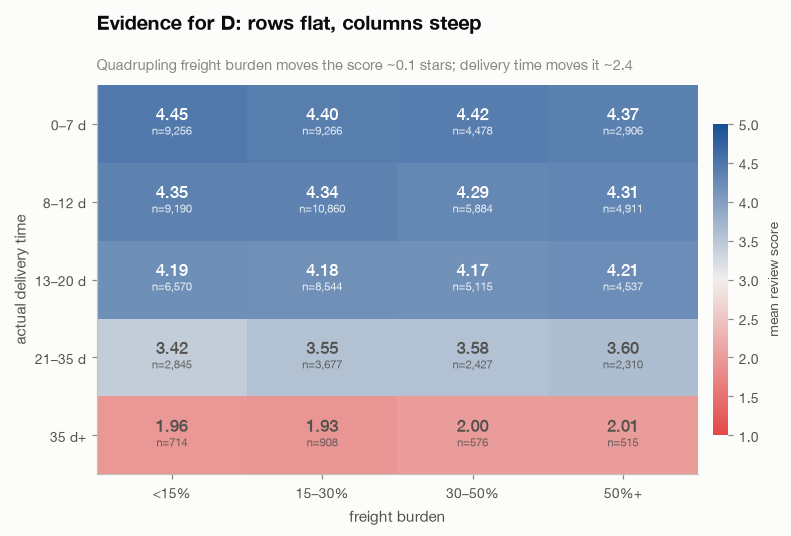

In [9]:
SAT = LinearSegmentedColormap.from_list("sat", [T.DIV_HIGH, T.DIV_MID, T.DIV_LOW])
cnt = od.groupby([db, fb], observed=True).review_score.size().unstack()

fig, ax = plt.subplots(figsize=(8.5, 4.6))
im = ax.imshow(piv, cmap=SAT, vmin=1, vmax=5, aspect="auto")
ax.set_xticks(range(piv.shape[1]), piv.columns)
ax.set_yticks(range(piv.shape[0]), piv.index)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = piv.iloc[i, j]
        if pd.isna(v):
            continue
        ink = "#ffffff" if abs(v - 3) > 1.15 else T.INK_2
        ax.text(j, i, f"{v:.2f}", ha="center", va="bottom", fontsize=11,
                color=ink, fontweight="medium")
        ax.text(j, i, f"n={cnt.iloc[i,j]:,.0f}", ha="center", va="top",
                fontsize=7.5, color=ink, alpha=0.85)
cb = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cb.set_label("mean review score", color=T.INK_2, fontsize=9)
cb.outline.set_visible(False)
T.title(ax, "Evidence for D: rows flat, columns steep",
        "Quadrupling freight burden moves the score ~0.1 stars; delivery time moves it ~2.4")
ax.set_xlabel("freight burden"); ax.set_ylabel("actual delivery time")
ax.grid(visible=False)
plt.show()

**The causal structure this implies**

```
                  ┌──────────> freight ─────╳──> rating
                  │                  (no independent link)
   distance ──────┼──────────> delivery time ──┐
                  │                            ├──> expectation error ──> RATING
                  └──────────> promise ────────┘
```

**Strength.** The most methodologically defensible of the four, because its central
claim is about the limits of the evidence rather than a finding that can be
contradicted.

**Risk.** If the marking scheme rewards findings over rigour, a project whose headline
is "this relationship isn't real" can read as thin. Check the rubric before committing
to D as the spine.

## 6. Comparison and recommendation

In [10]:
summary = pd.DataFrame([
    {"": "A", "problem statement": "Consolidation penalty",
     "headline evidence": f"R$ {overpay.sum():,.0f} overpaid ({100*overpay.sum()/FREIGHT_TOTAL:.0f}% of freight)",
     "charts": 3, "risk": "counterfactual is an assumption"},
    {"": "B", "problem statement": "Regressive freight",
     "headline evidence": f"burden {band.median_burden.iloc[0]:.0f}% -> {band.median_burden.iloc[-1]:.0f}% across price bands",
     "charts": 4, "risk": "tariff fit explains 57% of variance"},
    {"": "C", "problem statement": "Two freight problems",
     "headline evidence": f"SP->SP = {100*items.loc[sp_sp,'freight_value'].sum()/FREIGHT_TOTAL:.0f}% of spend at {items.loc[sp_sp,'km'].median():.0f} km",
     "charts": 2, "risk": "thin as a standalone project"},
    {"": "D", "problem statement": "What freight does not explain",
     "headline evidence": "freight effect ~0.1 stars vs delivery ~2.4 stars",
     "charts": 2, "risk": "a null headline may read as thin"},
]).set_index("")
summary

,problem statement,headline evidence,charts,risk
,,,,
A,Consolidation penalty,"R$ 234,120 overpaid (10% of freight)",3,counterfactual is an assumption
B,Regressive freight,burden 62% -> 4% across price bands,4,tariff fit explains 57% of variance
C,Two freight problems,SP->SP = 21% of spend at 95 km,2,thin as a standalone project
D,What freight does not explain,freight effect ~0.1 stars vs delivery ~2.4 stars,2,a null headline may read as thin


### Recommendation

**Use B as the spine, A as the commercial payoff, D as the closing section, and fold C
into B's geography part.**

The four are not independent — they are one argument told in sequence:

1. **B** establishes the *mechanism*: a fixed base fee, recovered from the data, that
   makes freight regressive by construction.
2. **C** shows that mechanism playing out across geography, and separates the cost
   problem from the equity one.
3. **A** converts the mechanism into *money*, and connects it to the marketplace's
   weakest metric — a 3% repeat rate.
4. **D** stops the argument overreaching, by showing the harm you would most like to
   claim is not visible in the data and explaining precisely why.

That sequence gives a mechanism, a quantification, a surprise, and a limitation — which
is a complete piece of analytical work rather than a collection of charts.

### Limitations that apply to all four

* **`freight_value` is revenue, not cost.** No carrier or cost table exists in any of
  the nine files, so profitability, subsidy and margin claims are unavailable. This is
  the hardest constraint on the whole topic and should appear early, not in a footnote.
* **Distances are great-circle**, not road distance, so true transport distance is
  understated — especially across Brazil's interior.
* **Everything conditions on completed orders.** Customers deterred by freight before
  checkout are structurally unobservable, so no result here speaks to demand destruction.
* **The window is ~2 years ending mid-October 2018**, with the last month partial.